### KMeans (Lloyd's algorithm)
- Goal : Implement KMeans from scratch using Numpy
- We will implement it twice, one using a simple 2d data (synthetic) and an actual data (most probably sklearn's diabetes data - by excluding y)

#### KMeans using 2D data

In [2]:
import numpy as np
import matplotlib.pyplot as plt #I WILL USE AI FOR PLOTTING FOR SURE!!!

rndGen = np.random.default_rng(seed=15)
X = rndGen.random((1000, 2))

print(X.shape)

(1000, 2)


In [3]:
def inertia(X, cPt):
    #Measures compactness
    return np.sum((X - cPt) ** 2)

In [4]:
def computeCentroid(X):
    return np.mean(X, axis=0) #Computes mean over features

In [5]:
def assignClusters(X, cPts):
    clusters = {i: [] for i in range(len(cPts))}

    for x in X:
        distances = np.sum((cPts - x) ** 2, axis=1) #Euc.Distance by broadcasting
        clusterIdx = np.argmin(distances) #Nearest centroid's index
        clusters[clusterIdx].append(x) # Assign point

    return clusters

In [6]:
def updateCentroids(clusters):
    cPts = []

    for i in clusters:

        clusterPoints = np.array(clusters[i])
        centroid = computeCentroid(clusterPoints)

        cPts.append(centroid)

    return np.array(cPts)

In [7]:
def KMeans(X, k, maxIter=100, margin=1e-6):
    randomIdx = rndGen.choice(len(X), size=k, replace=False)
    cPts = X[randomIdx]

    for count in range(maxIter):
        clusters = assignClusters(X, cPts) # Assign pts to nearest centroid

        newCPts = updateCentroids(clusters) #Updat ethe centroids

        if np.allclose(cPts, newCPts, atol=margin): #Convergence check. If old centroids and new ones are vlose then break
            break

        cPts = newCPts

    return clusters, cPts

In [8]:
'''
clusters, cPts = KMeans(X, k=3)

print(cPts,'\n')

for i in clusters:
    print(f"Cluster {i} : {len(clusters[i])} pts")

totalInertia = 0

for i in clusters:

    clusterPoints = np.array(clusters[i])
    totalInertia += inertia(clusterPoints, cPts[i])

print('\n',totalInertia)
'''

'\nclusters, cPts = KMeans(X, k=3)\n\nprint(cPts,\'\n\')\n\nfor i in clusters:\n    print(f"Cluster {i} : {len(clusters[i])} pts")\n\ntotalInertia = 0\n\nfor i in clusters:\n\n    clusterPoints = np.array(clusters[i])\n    totalInertia += inertia(clusterPoints, cPts[i])\n\nprint(\'\n\',totalInertia)\n'

In [9]:
# ELBOWWWWWW!!!
kMax = int(np.sqrt(len(X)))

kVals = []
inertiaVals = []

for k in range(kMax, 0, -1):

    clusters, cPts = KMeans(X, k)

    totalInertia = 0

    for i in clusters:

        clusterPoints = np.array(clusters[i])
        totalInertia += inertia(clusterPoints, cPts[i])

    kVals.append(k)
    inertiaVals.append(totalInertia)

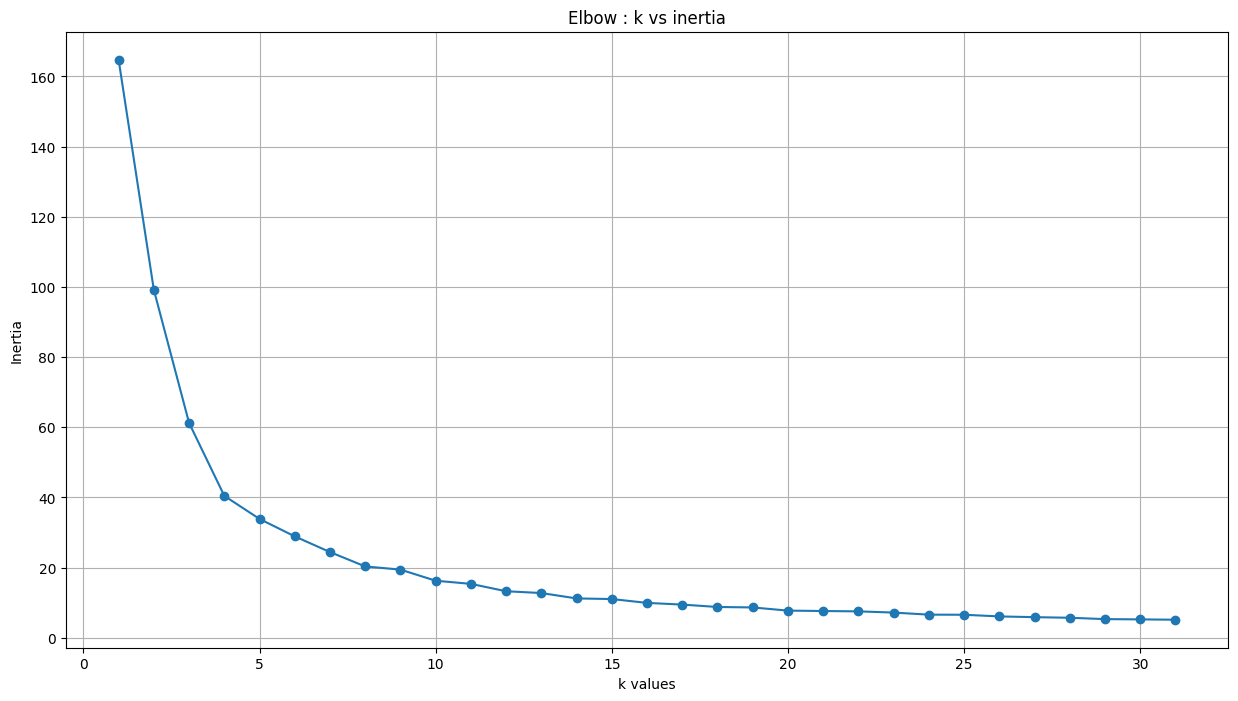

In [10]:
kVals = kVals[::-1]
inertiaVals = inertiaVals[::-1]

plt.figure(figsize = (15,8))

plt.plot(kVals, inertiaVals, marker="o")

plt.xlabel("k values")
plt.ylabel("Inertia")
plt.title("Elbow : k vs inertia")

plt.grid(True)

plt.show()

##### We will be assigning the best K manually by checking the scree plot of inertia. Put the best value for K

In [11]:
bestK = int(input("Best k :"))

Best k : 6


In [12]:
def plotClusters(X, clusters, cPts):
    plt.figure(figsize=(15, 8))

    for i in clusters:

        clusterPoints = np.array(clusters[i])

        plt.scatter(
            clusterPoints[:, 0],
            clusterPoints[:, 1],
            s=20,
            label=f"Cluster {i}"
        )

    plt.scatter(
        cPts[:, 0],
        cPts[:, 1],
        marker="X",
        s=200,
        c="black",
        label="Centroids"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("KMeans Clustering")
    #plt.legend()

    plt.show()

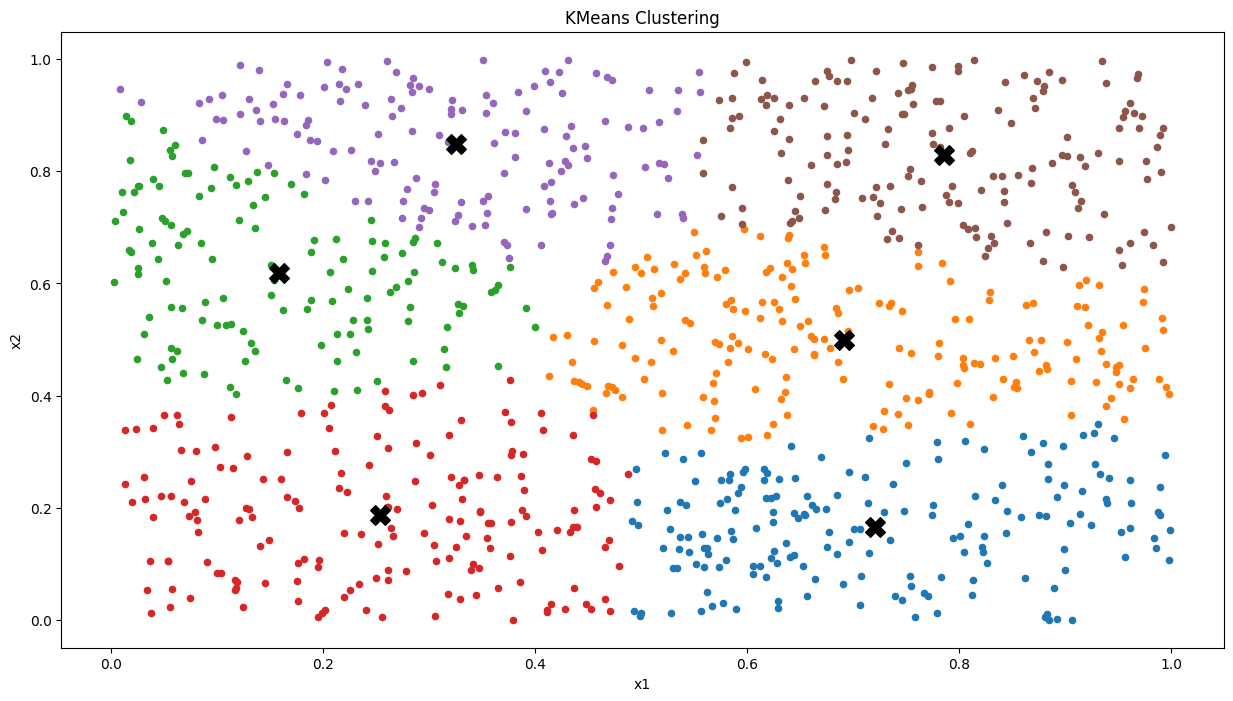

In [13]:
clusters, cPts = KMeans(X, bestK)

plotClusters(X, clusters, cPts)